In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import cv2
import sys
import pandas as pd
from torch.utils.data import Dataset

class FaceDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = int(self.df.iloc[idx]['id'])
        img_path = os.path.join(self.img_dir, f"face-{img_id}.png")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        return image

In [7]:
sys.path.append("../")
from torch.utils.data import DataLoader
from src.utils.augmentations import get_train_transform
from src.utils.augmentations import denormalize
from src.models.diffusion import DiffusionModel


device = "cuda"

dataset = FaceDataset(
    csv_path="../data/train.csv",
    img_dir="../data/processed_64",
    transform=get_train_transform(64)
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [5]:
device = "cuda"
import torch

# model = DiffusionModel(device=device, timesteps=1000, img_size=64)
# epochs = 250
# model.fit(dataloader, epochs=epochs, lr=5e-5)
# checkpoint = f"../models/diffusion_model_{epochs}.pth"

# torch.save({"model": model.model.state_dict(), "ema_model": model.ema_model.state_dict()}, checkpoint)

In [ ]:
# Train 6 different diffusion models, changing one parameter at a time (max batch size 32)
import torch
import torchvision
import matplotlib.pyplot as plt

# Base config (already trained above)
base_cfg = {"timesteps": 1000, "lr": 5e-5, "batch_size": 32, "epochs": 100}

# Only one parameter changes per config (exclude base config)
configs = [
    {**base_cfg},            # base model
    {**base_cfg, "batch_size": 16},           # lower batch size
    {**base_cfg, "timesteps": 500},            # lower timesteps
    {**base_cfg, "lr": 1e-4},                 # change learning rate
    # {**base_cfg, "epochs": 250},              # change epochs
    {**base_cfg, "beta_end": 0.01},           # less noise injected
]

for i, cfg in enumerate(configs, 1):
    print(f"\nTraining model {i} with timesteps={cfg['timesteps']}, lr={cfg['lr']}, batch_size={cfg['batch_size']}, epochs={cfg['epochs']}" + (f", beta_end={cfg['beta_end']}" if 'beta_end' in cfg else '') + (f", channels={cfg['channels']}" if 'channels' in cfg else ''))
    dataloader = DataLoader(dataset, batch_size=cfg["batch_size"], shuffle=True)
    model_kwargs = {"device": device, "timesteps": cfg["timesteps"], "img_size": 64}
    if "beta_end" in cfg:
        model_kwargs["beta_end"] = cfg["beta_end"]
    if "channels" in cfg:
        model_kwargs["channels"] = cfg["channels"]
    model = DiffusionModel(**model_kwargs)
    model.fit(dataloader, epochs=cfg["epochs"], lr=cfg["lr"])
    # Save with parameters in filename
    extra = ""
    if "beta_end" in cfg:
        extra += f"_be{cfg['beta_end']}"
    if "channels" in cfg:
        extra += f"_ch{cfg['channels']}"
    checkpoint = (
        f"../outputs/Diffusion_images/diffusion_t{cfg['timesteps']}_lr{cfg['lr']}_bs{cfg['batch_size']}_ep{cfg['epochs']}{extra}.pth"
    )
    torch.save({"model": model.model.state_dict(), "ema_model": model.ema_model.state_dict()}, checkpoint)
    print(f"Saved checkpoint: {checkpoint}")

    # Sample 12 images and save grid with same parameters
    samples = model.sample(n=12, use_ema=True)
    samples = (samples.clamp(-1, 1) + 1) / 2
    grid = torchvision.utils.make_grid(samples, nrow=4, padding=2)
    img_path = checkpoint.replace(".pth", "_samples.png")
    torchvision.utils.save_image(grid, img_path)
    print(f"Saved sample grid: {img_path}")


Training model 1 with timesteps=1000, lr=5e-05, batch_size=32, epochs=100


Epoch 100/100: 100%|██████████| 141/141 [00:25<00:00,  5.48it/s, loss=0.0089]


Saved checkpoint: ../models/diffusion_t1000_lr5e-05_bs32_ep100.pth


Sampling: 100%|██████████| 1000/1000 [00:19<00:00, 52.47it/s]


Saved sample grid: ../models/diffusion_t1000_lr5e-05_bs32_ep100_samples.png

Training model 2 with timesteps=1000, lr=5e-05, batch_size=16, epochs=100


...

Saved sample grid: ../models/diffusion_t1000_lr0.0001_bs32_ep100_samples.png

Training model 5 with timesteps=1000, lr=5e-05, batch_size=32, epochs=100, beta_end=0.01


Epoch 100/100: 100%|██████████| 141/141 [00:25<00:00,  5.49it/s, loss=0.0348]


Saved checkpoint: ../models/diffusion_t1000_lr5e-05_bs32_ep100_be0.01.pth


Sampling: 100%|██████████| 1000/1000 [00:19<00:00, 52.48it/s]


Saved sample grid: ../models/diffusion_t1000_lr5e-05_bs32_ep100_be0.01_samples.png


In [ ]:
# import torchvision

# # checkpoint = f"../models/diffusion_model_{epochs}.pth"
# # epochs = 1
# # model = DiffusionModel(device=device, timesteps=1000, img_size=64)
# # ckpt  = torch.load(checkpoint, map_location=device)
# # model.model.load_state_dict(ckpt["model"])
# # model.ema_model.load_state_dict(ckpt["ema_model"])


# # --- Sample ---
# samples = model.sample(n=16, use_ema=True)
# # --- Rescale [-1, 1] → [0, 1] and save grid ---
# samples = (samples.clamp(-1, 1) + 1) / 2
# grid    = torchvision.utils.make_grid(samples, nrow=4, padding=2)
# torchvision.utils.save_image(grid, f"../outputs/Diffusion_images/generated_{epochs}.png")

Sampling: 100%|██████████| 1000/1000 [00:25<00:00, 39.73it/s]


Found 6 model checkpoints:
diffusion_model_250.pth
diffusion_t1000_lr0.0001_bs32_ep100.pth
diffusion_t1000_lr5e-05_bs16_ep100.pth
diffusion_t1000_lr5e-05_bs32_ep100.pth
diffusion_t1000_lr5e-05_bs32_ep100_be0.01.pth
diffusion_t500_lr5e-05_bs32_ep100.pth


Sampling: 100%|██████████| 1000/1000 [01:36<00:00, 10.37it/s]


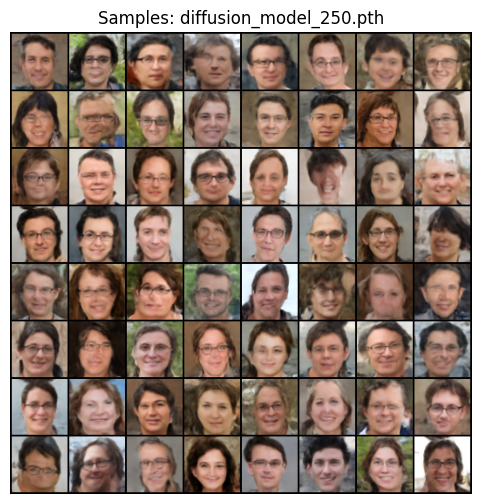

/mnt/Acads and Codes/VScode_Files/Projects/GenAI/Assignment1/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Model: diffusion_model_250.pth | FID: 100.06 | IS: 1.45 ± 0.23


Sampling: 100%|██████████| 1000/1000 [01:37<00:00, 10.30it/s]


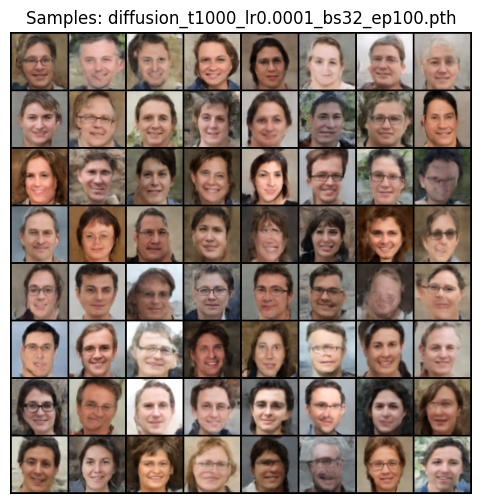

Model: diffusion_t1000_lr0.0001_bs32_ep100.pth | FID: 88.65 | IS: 1.44 ± 0.20


Sampling: 100%|██████████| 1000/1000 [01:37<00:00, 10.27it/s]


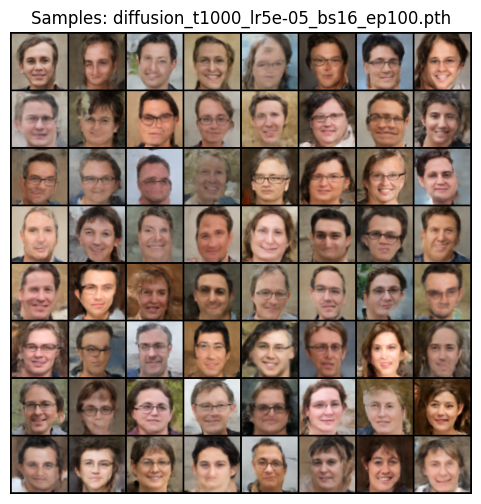

Model: diffusion_t1000_lr5e-05_bs16_ep100.pth | FID: 89.68 | IS: 1.43 ± 0.18


Sampling: 100%|██████████| 1000/1000 [01:37<00:00, 10.27it/s]


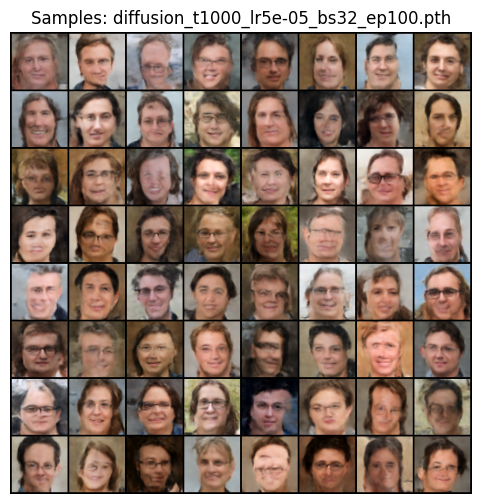

Model: diffusion_t1000_lr5e-05_bs32_ep100.pth | FID: 110.89 | IS: 1.39 ± 0.19


Sampling: 100%|██████████| 1000/1000 [01:37<00:00, 10.26it/s]


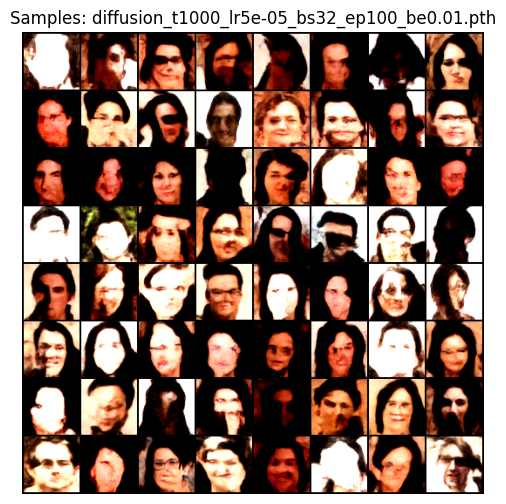

Model: diffusion_t1000_lr5e-05_bs32_ep100_be0.01.pth | FID: 257.43 | IS: 1.98 ± 0.49


Sampling: 100%|██████████| 1000/1000 [01:37<00:00, 10.25it/s]


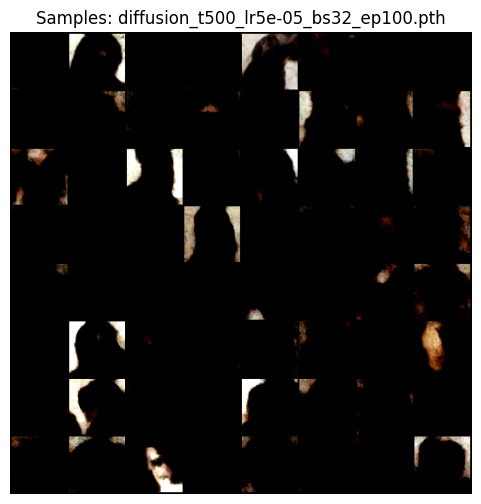

Model: diffusion_t500_lr5e-05_bs32_ep100.pth | FID: 480.74 | IS: 1.69 ± 0.32


,model,FID,IS,IS_std,img_path
0,diffusion_model_250.pth,100.063080,1.454271,0.232347,../models/diffusion_model_250_samples.png
1,diffusion_t1000_lr0.0001_bs32_ep100.pth,88.649300,1.439279,0.204419,../models/diffusion_t1000_lr0.0001_bs32_ep100_...
2,diffusion_t1000_lr5e-05_bs16_ep100.pth,89.675568,1.431635,0.180988,../models/diffusion_t1000_lr5e-05_bs16_ep100_s...
3,diffusion_t1000_lr5e-05_bs32_ep100.pth,110.888855,1.392715,0.193197,../models/diffusion_t1000_lr5e-05_bs32_ep100_s...
4,diffusion_t1000_lr5e-05_bs32_ep100_be0.01.pth,257.434631,1.981505,0.486532,../models/diffusion_t1000_lr5e-05_bs32_ep100_b...
5,diffusion_t500_lr5e-05_bs32_ep100.pth,480.741333,1.685951,0.315514,../models/diffusion_t500_lr5e-05_bs32_ep100_sa...


In [ ]:
import pandas as pd
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

# 2. UPDATED EVALUATION LOOP
results = []

real_images_dir = "../data/processed_64"
models_dir = "../models"

for ckpt_path in models_dir:
    print(f"Evaluating {os.path.basename(ckpt_path)}...")
    
    # Load model (Ensure your UNet matches the architecture used during training!)
    model = DiffusionModel(device=device, timesteps=1000, img_size=64)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.model.load_state_dict(ckpt["model"])
    model.ema_model.load_state_dict(ckpt["ema_model"])

    # Generate samples for metrics (64 is a good small-scale test)
    # FID is more stable with 1000+ images, but 64 works for a quick ablation
    with torch.no_grad():
        samples = model.sample(n=64, use_ema=True) # Returns [-1, 1]
    
    # Create human-readable [0, 1] version for display/saving
    samples_01 = denormalize(samples)
    
    # Save the 8x8 grid for your report
    grid = torchvision.utils.make_grid(samples_01, nrow=8, padding=2)
    img_path = ckpt_path.replace(".pth", "_grid.png")
    torchvision.utils.save_image(grid, img_path)

    # Prepare images for Metrics (Must be uint8 [0, 255])
    fake_imgs_uint8 = (samples_01 * 255).to(torch.uint8)

    # Load real images (subset for comparison)
    real_imgs_list = []
    real_files = glob(os.path.join(real_images_dir, "*"))[:64]
    for fname in real_files:
        img = Image.open(fname).convert('RGB').resize((64, 64))
        real_imgs_list.append(torchvision.transforms.ToTensor()(img))
    
    real_imgs_01 = torch.stack(real_imgs_list).to(device)
    real_imgs_uint8 = (real_imgs_01 * 255).to(torch.uint8)

    # Compute FID (Frechet Inception Distance)
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    fid_metric.update(real_imgs_uint8, real=True)
    fid_metric.update(fake_imgs_uint8, real=False)
    fid_score = fid_metric.compute().item()

    # Compute IS (Inception Score)
    is_metric = InceptionScore().to(device)
    is_metric.update(fake_imgs_uint8)
    is_mean, is_std = is_metric.compute()

    # Store results with the path to the human-readable image
    results.append({
        "Model Configuration": os.path.basename(ckpt_path),
        "FID (Lower is better)": round(fid_score, 2),
        "IS (Higher is better)": round(is_mean.item(), 2),
        "Sample Grid": img_path
    })

# 3. DISPLAY FINAL TABLE
df = pd.DataFrame(results)

# To actually see the images in the Jupyter/Colab table:
from IPython.display import Image as IPImage, display, HTML

def show_image(path):
    return f'<img src="{path}" width="150" >'

display(HTML(df.to_html(escape=False, formatters={'Sample Grid': show_image})))